In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv('../data/sales_train_validation.csv')
calendar = pd.read_csv('../data/calendar.csv')
prices = pd.read_csv('../data/sell_prices.csv')

In [6]:
# Look the structure
print('sales shape:', sales.shape)
print('calendar shape:', calendar.shape)
print('prices shape:', prices.shape)

sales shape: (30490, 1919)
calendar shape: (1969, 14)
prices shape: (6841121, 4)


***Sales File***

In [8]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [9]:
print(sales.columns.tolist())

['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_84', 'd_85', 'd_86', 'd_87', 'd_88', 'd_89', 'd_90', 'd_91', 'd_92', 'd_93', 'd_94', 'd_95', 'd_96', 'd_97', 'd_98', 'd_99', 'd_100', 'd_101', 'd_102', 'd_103', 'd_104', 'd_105', 'd_106', 'd_107', 'd_108', 'd_109', 'd_110', 'd_111', 'd_112', 'd_113', 'd_114', 'd_115', 'd_116', '

In [10]:
day_cols = [c for c in sales.columns if c.startswith('d_')]
zero_ratio = (sales[day_cols] == 0).sum().sum() / (sales.shape[0] * len(day_cols))
print(f'zero ratio: {zero_ratio:.2%}')

zero ratio: 68.20%


***Calendar File***

In [21]:
calendar.tail()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


In [13]:
print(calendar['event_name_1'].dropna().unique())

['SuperBowl' 'ValentinesDay' 'PresidentsDay' 'LentStart' 'LentWeek2'
 'StPatricksDay' 'Purim End' 'OrthodoxEaster' 'Pesach End' 'Cinco De Mayo'
 "Mother's day" 'MemorialDay' 'NBAFinalsStart' 'NBAFinalsEnd'
 "Father's day" 'IndependenceDay' 'Ramadan starts' 'Eid al-Fitr'
 'LaborDay' 'ColumbusDay' 'Halloween' 'EidAlAdha' 'VeteransDay'
 'Thanksgiving' 'Christmas' 'Chanukah End' 'NewYear' 'OrthodoxChristmas'
 'MartinLutherKingDay' 'Easter']


In [14]:
print(calendar['event_name_2'].dropna().unique())

['Easter' 'Cinco De Mayo' 'OrthodoxEaster' "Father's day"]


In [15]:
print('CA SNAP days:', calendar['snap_CA'].sum())
print('TX SNAP days:', calendar['snap_TX'].sum())
print('WI SNAP days:', calendar['snap_WI'].sum())

CA SNAP days: 650
TX SNAP days: 650
WI SNAP days: 650


***Price File***

In [16]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [17]:
prices['sell_price'].describe()

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

In [18]:
print('Items:', prices['item_id'].nunique())
print('Stores:', prices['store_id'].nunique())

Items: 3049
Stores: 10


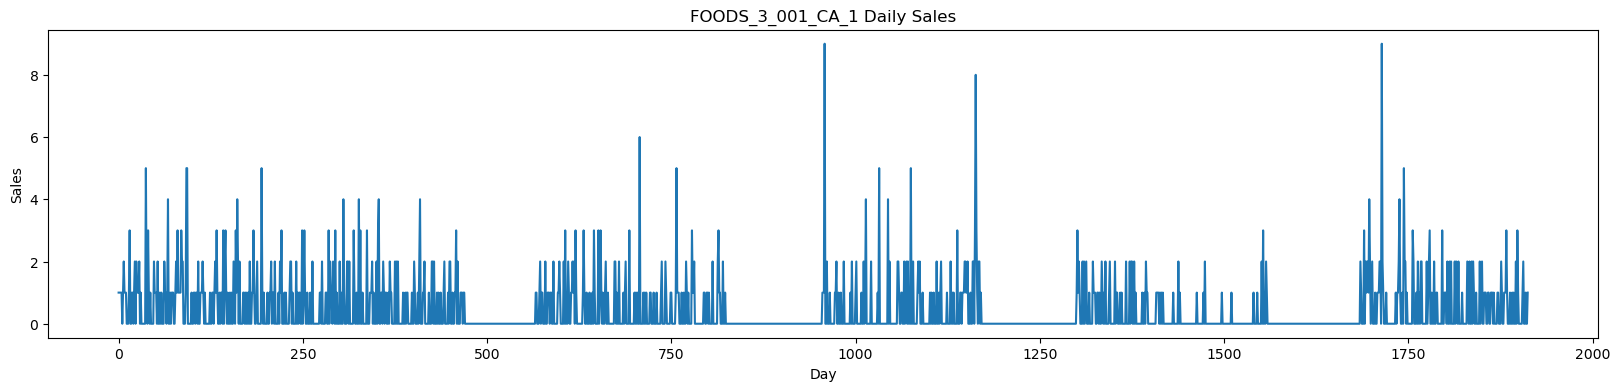

In [20]:
# A time siries plot for a random item
item = sales[sales['id'] == 'FOODS_3_001_CA_1_validation']
item_values = item[day_cols].values.flatten()

plt.figure(figsize=(20, 4))
plt.plot(item_values)
plt.title('FOODS_3_001_CA_1 Daily Sales')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.show()

***Average Sales by Weekday***

In [22]:
sales_melted = sales[['id'] + day_cols[:365]].melt(
    id_vars='id',
    var_name='d',
    value_name='sales'
)

In [25]:
sales_melted

,id,d,sales,weekday
0,HOBBIES_1_001_CA_1_validation,d_1,0,Saturday
1,HOBBIES_1_002_CA_1_validation,d_1,0,Saturday
2,HOBBIES_1_003_CA_1_validation,d_1,0,Saturday
3,HOBBIES_1_004_CA_1_validation,d_1,0,Saturday
4,HOBBIES_1_005_CA_1_validation,d_1,0,Saturday
...,...,...,...,...
11128845,FOODS_3_823_WI_3_validation,d_365,0,Saturday
11128846,FOODS_3_824_WI_3_validation,d_365,0,Saturday
11128847,FOODS_3_825_WI_3_validation,d_365,1,Saturday
11128848,FOODS_3_826_WI_3_validation,d_365,0,Saturday


In [24]:
sales_melted = sales_melted.merge(calendar[['d', 'weekday']], on='d')

In [28]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly = sales_melted.groupby('weekday')['sales'].mean()
weekly = weekly.reindex(weekday_order)
print(weekly)

weekday
Monday       0.828031
Tuesday      0.772496
Wednesday    0.758725
Thursday     0.768813
Friday       0.881390
Saturday     1.059673
Sunday       1.007114
Name: sales, dtype: float64


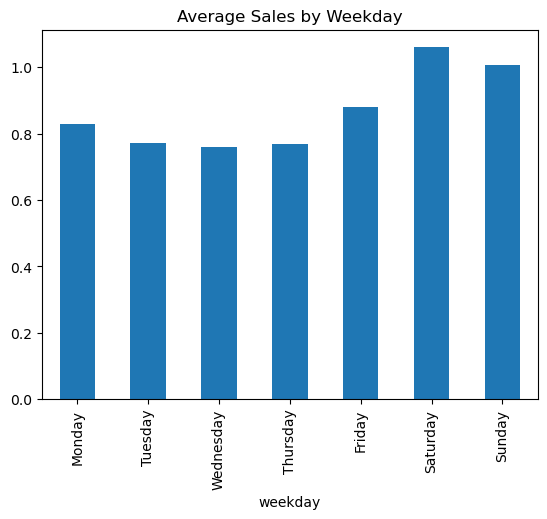

In [29]:
weekly.plot(kind='bar', title='Average Sales by Weekday')
plt.show()

***Sales Across Level***

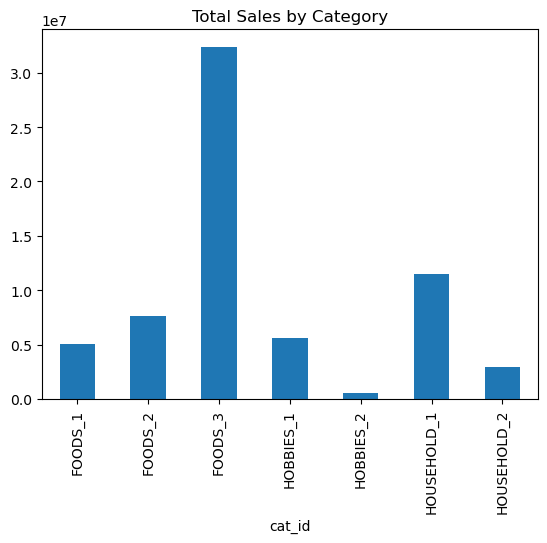

In [30]:
sales['cat_id'] = sales['id'].str.split('_').str[:2].str.join('_')

category_sales = sales.groupby('cat_id')[day_cols].sum().sum(axis=1)
category_sales.plot(kind='bar', title='Total Sales by Category')
plt.show()

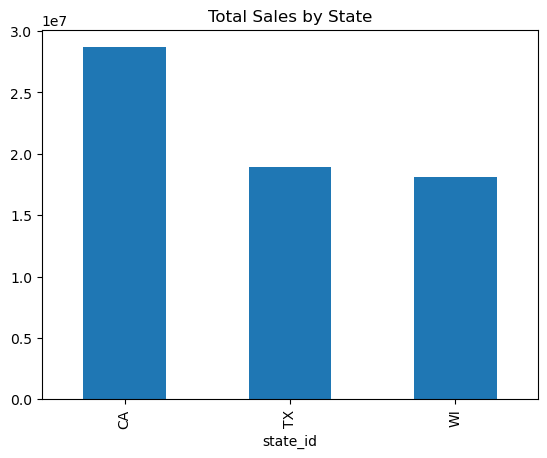

In [32]:
sales['state_id'] = sales['id'].str.split('_').str[3]
state_sales = sales.groupby('state_id')[day_cols].sum().sum(axis=1)
state_sales.plot(kind='bar', title='Total Sales by State')
plt.show()